# Qiskit QPE Experiment with Mid-Circuit Measurements

This notebook implements a two-stage QPE experiment using Qiskit's mid-circuit measurement support.

**Key idea (different from the Braket single-circuit approach):**
1. **Stage 1 – Token Generation**: QPE runs on `prec1` (precision) + `target` qubits. `prec1` is then *measured mid-circuit*, which **collapses** the target qubit onto an eigenstate of U with a definite phase.
2. **Stage 2 – Verification**: A fresh QPE runs on `prec2` + the *same (collapsed) target* qubits. Because the target is now a phase eigenstate, the second measurement should agree with the first.

In the Braket version both QPE circuits ran without any collapse between them (no mid-circuit measurement). Here each shot independently collapses the state, making this a true sequential protocol.

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator

## Helper functions

In [30]:
def haar_random_unitary(d: int, rng=None) -> np.ndarray:
    """Generate a d×d Haar-random unitary via QR decomposition."""
    rng = rng or np.random.default_rng()
    z = (rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))) / np.sqrt(2.0)
    q, r = np.linalg.qr(z)
    diag = np.diag(r)
    phases = diag / np.abs(diag)
    phases[np.abs(diag) == 0] = 1.0
    return q * phases

In [31]:
def random_circuit_state(qc: QuantumCircuit, qubits, depth: int = 3, rng=None):
    """Initialise qubits in a random state using U3 + CNOT layers (Qiskit convention)."""
    rng = rng or np.random.default_rng()
    for _ in range(depth):
        for q in qubits:
            theta, phi, lam = rng.uniform(0, 2 * np.pi, size=3)
            qc.u(theta, phi, lam, q)   # most-general single-qubit gate
        for i in range(len(qubits) - 1):
            qc.cx(qubits[i], qubits[i + 1])
    return qc

In [32]:
def build_qpe_circuit(n_prec: int, unitary_matrix: np.ndarray) -> QuantumCircuit:
    """
    Build a QPE sub-circuit for a given unitary matrix.

    Qubit layout inside the returned circuit:
        [prec[0], prec[1], ..., prec[n_prec-1],  ← precision / evaluation qubits
         targ[0], targ[1], ..., targ[n_targ-1]]  ← target / state qubits

    Steps:
        1. Hadamard on all precision qubits.
        2. Controlled-U^(2^k) for k = 0 … n_prec-1  (prec[k] is the control).
        3. Inverse QFT on precision qubits.
    """
    n_targ = int(round(np.log2(len(unitary_matrix))))
    total  = n_prec + n_targ

    qc   = QuantumCircuit(total, name='QPE')
    prec = list(range(n_prec))
    targ = list(range(n_prec, total))

    # Step 1: Hadamard
    qc.h(prec)

    # Step 2: Controlled-U^(2^k)
    for k in range(n_prec):
        u_pow  = np.linalg.matrix_power(unitary_matrix, 2 ** k)
        cu_gate = UnitaryGate(u_pow, label=f'U^2^{k}').control(1)
        qc.append(cu_gate, [prec[k]] + targ)

    # Step 3: Inverse QFT  (do_swaps=True is the default and gives natural bit order)
    iqft = QFT(n_prec, inverse=True, do_swaps=True)
    qc.append(iqft, prec)

    return qc

In [33]:
def boundary_function(eps):
    pi = np.pi
    return ( 1 - (2 / pi**2 )*( np.sqrt(eps) + 1 )/ 2 ) * ( 1 - ( 2 / pi**2 )*( ( eps - 1 ) / 2 ) )

def lower_bound_verified_prob(eps):
    f = boundary_function(eps)

    return ( 1- np.sqrt(1-f))**2

def cyclic_distance(a: int, b: int, n_prec: int) -> int:
    """Cyclic distance |a - b| mod 2^n_prec."""
    M    = 2 ** n_prec
    diff = abs(a - b)
    return min(diff, M - diff)

def parse_outcome(bitstring: str, n_prec: int):
    """
    Parse a Qiskit count key that contains two named ClassicalRegisters.

    Qiskit formats the key as  'c2_bits c1_bits'  (space-separated):
        • the LAST register added to the circuit appears on the LEFT (most significant).
        • within each register, bits are big-endian (reg[n-1] … reg[0] left-to-right).

    Here c1 was added before c2, so:
        parts[0] = c2 = second QPE result
        parts[1] = c1 = first QPE result

    Returns (m1, m2) as integers.
    """
    parts  = bitstring.split(' ')
    c2_str = parts[0]   # second QPE
    c1_str = parts[1]   # first  QPE
    return int(c1_str, 2), int(c2_str, 2)

## Parameters

In [34]:
n_prec  = 6      # precision qubits per QPE stage
n_targ  = 3      # target qubits  (unitary acts on 2^n_targ dimensional space)
n_shots = 2000   # number of shots
delta   = 4      # acceptance threshold for cyclic distance

rng     = np.random.default_rng(seed=42)
unitary = haar_random_unitary(2 ** n_targ, rng=rng)

print(f'n_prec={n_prec}, n_targ={n_targ}, delta={delta}')
print(f'Unitary eigenvalues: {np.linalg.eigvals(unitary)}')

n_prec=6, n_targ=3, delta=4
Unitary eigenvalues: [ 0.31749864+0.94825873j  0.76718306+0.64142821j -0.5801523 +0.81450802j
 -0.99323738-0.11610131j -0.56363755-0.82602222j -0.09442362-0.99553211j
  0.64348371-0.7654598j   0.91593306-0.40133106j]


## Build the circuit with mid-circuit measurement

```
target  ──[random init]──────[QPE1 target]────────────────[QPE2 target]──
prec1   ──────────────────[QPE1 prec]──[M]→c1────────────────────────────
prec2   ─────────────────────────────────────────────[QPE2 prec]──[M]→c2─
```

The measurement `[M]→c1` is a **mid-circuit measurement**: it collapses `prec1` to a classical bitstring *and* projects the `target` qubit onto the corresponding eigenstate of U. The second QPE then operates on this collapsed state.

In [35]:
# ── Registers ──────────────────────────────────────────────────────────────
targ_reg  = QuantumRegister(n_targ, 'target')
prec1_reg = QuantumRegister(n_prec, 'prec1')
prec2_reg = QuantumRegister(n_prec, 'prec2')
c1        = ClassicalRegister(n_prec, 'c1')   # first  QPE result
c2        = ClassicalRegister(n_prec, 'c2')   # second QPE result

qc = QuantumCircuit(targ_reg, prec1_reg, prec2_reg, c1, c2)

# ── Initialise target in a random state ────────────────────────────────────
random_circuit_state(qc, list(targ_reg), depth=3, rng=rng)

# ── Stage 1: first QPE ─────────────────────────────────────────────────────
# QPE sub-circuit expects qubits in order [prec..., targ...]
qpe1 = build_qpe_circuit(n_prec, unitary)
qc.append(qpe1, list(prec1_reg) + list(targ_reg))

# ── MID-CIRCUIT MEASUREMENT ────────────────────────────────────────────────
# Measuring prec1 collapses the joint state; the target is projected onto
# the eigenstate of U whose phase was measured.
qc.measure(prec1_reg, c1)

qc.barrier(label='collapse')

# ── Stage 2: second QPE on the now-collapsed target ────────────────────────
qpe2 = build_qpe_circuit(n_prec, unitary)
qc.append(qpe2, list(prec2_reg) + list(targ_reg))

# ── Final measurement ──────────────────────────────────────────────────────
qc.measure(prec2_reg, c2)

print(f'Qubits : {qc.num_qubits}  |  Classical bits: {qc.num_clbits}')

Qubits : 15  |  Classical bits: 12


/var/folders/ll/9dhmfhz932g_qjcmrdtyvjjm0000gn/T/ipykernel_86925/4247251486.py:31: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(n_prec, inverse=True, do_swaps=True)


## Visualise the circuit (one level of decomposition)

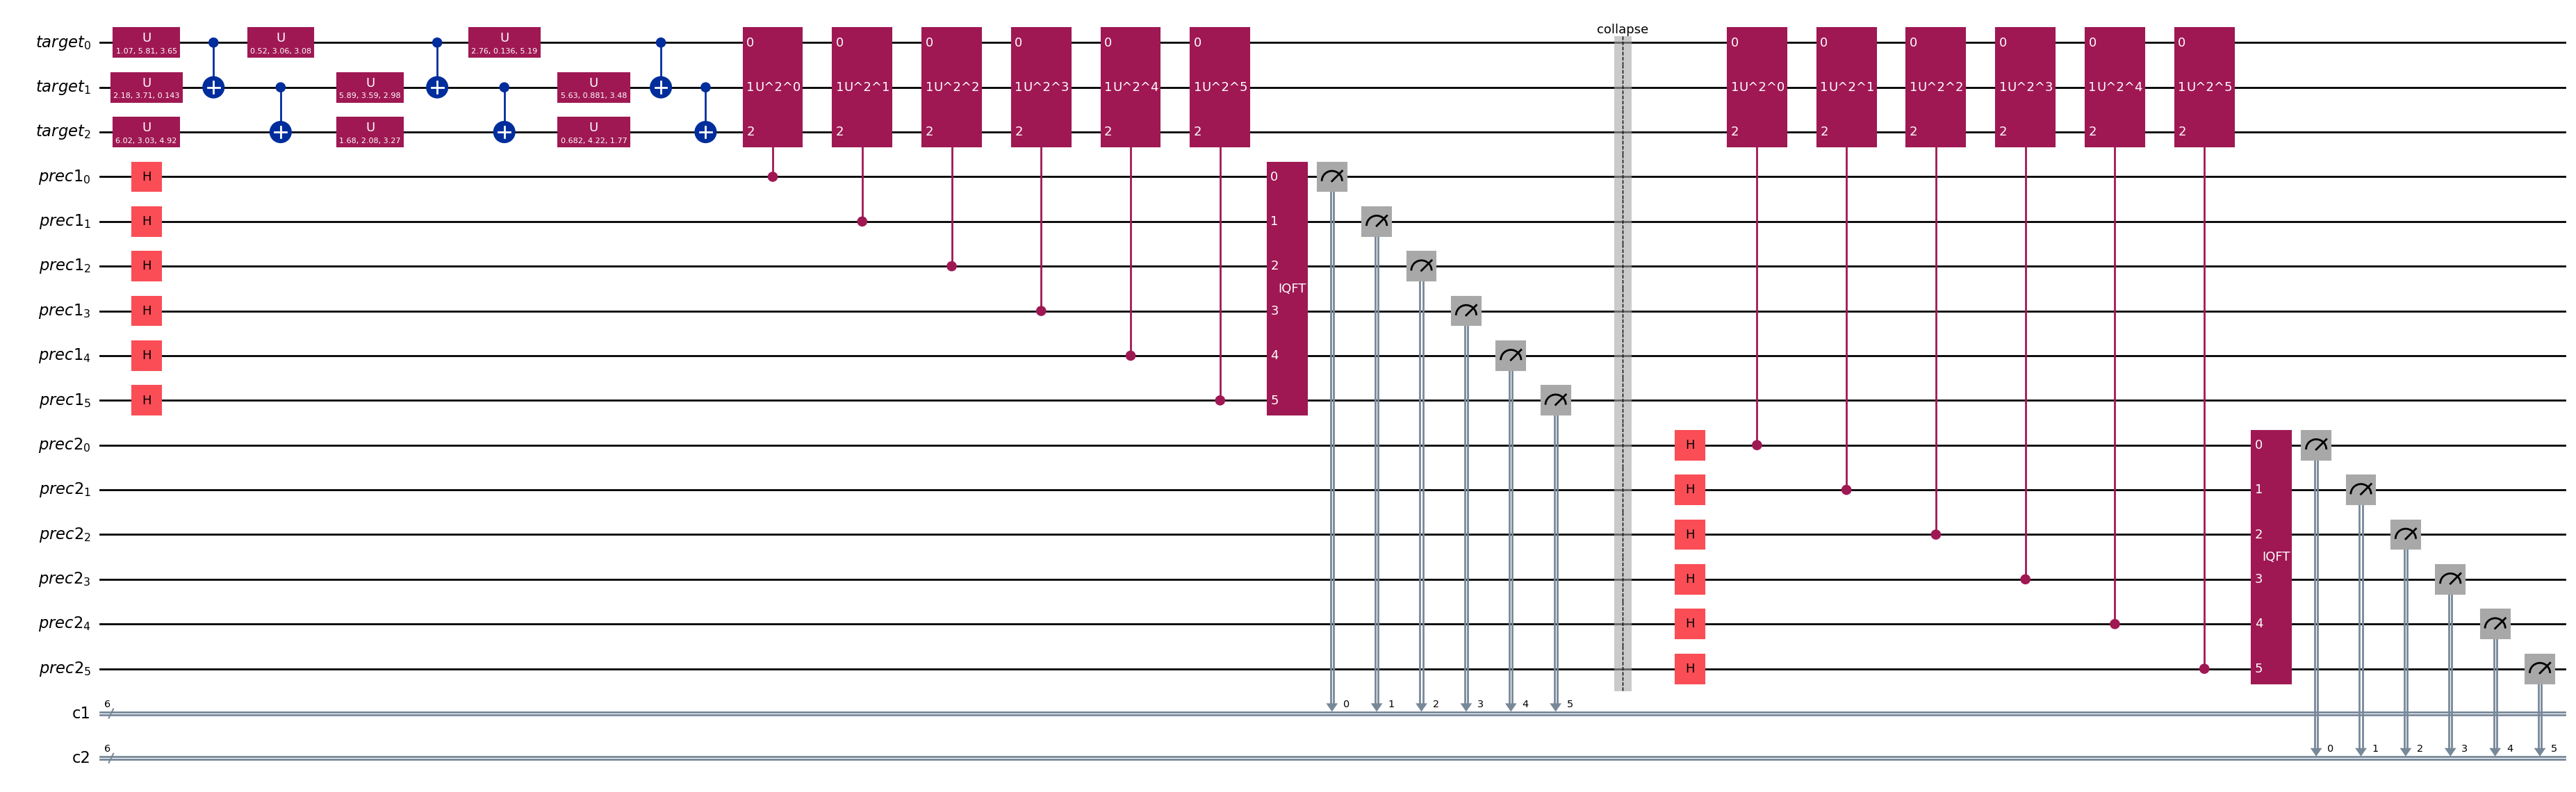

In [36]:
# Decompose once so QPE boxes expand but UnitaryGates stay compressed
qc.decompose(reps=1).draw(output='mpl', fold=120)

## Run on AerSimulator

`AerSimulator` supports dynamic / mid-circuit measurements out of the box.  
Each shot independently:
1. runs QPE1 and collapses `prec1` + `target` to a definite outcome,
2. runs QPE2 on the collapsed `target` and collapses `prec2`.


In [37]:
simulator    = AerSimulator()
transpiled   = transpile(qc, simulator)
job          = simulator.run(transpiled, shots=n_shots)
result       = job.result()
counts       = result.get_counts()

print(f'Unique outcomes : {len(counts)}')
print('Top 10:')
for k, v in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    m1, m2 = parse_outcome(k, n_prec)
    print(f'  {k!r:25s}  m1={m1:2d}  m2={m2:2d}  dist={cyclic_distance(m1,m2,n_prec)}  count={v}')

Unique outcomes : 148
Top 10:
  '101111 101111'            m1=47  m2=47  dist=0  count=315
  '010110 010110'            m1=22  m2=22  dist=0  count=306
  '100001 100001'            m1=33  m2=33  dist=0  count=300
  '101010 101010'            m1=42  m2=42  dist=0  count=202
  '000111 000111'            m1= 7  m2= 7  dist=0  count=149
  '110111 110111'            m1=55  m2=55  dist=0  count=146
  '001101 001101'            m1=13  m2=13  dist=0  count=68
  '111100 111100'            m1=60  m2=60  dist=0  count=60
  '010111 010110'            m1=22  m2=23  dist=1  count=58
  '010110 010111'            m1=23  m2=22  dist=1  count=52


## Analysis

In [38]:
total    = 0
accepted = 0

for outcome, count in counts.items():
    m1, m2 = parse_outcome(outcome, n_prec)
    dist    = cyclic_distance(m1, m2, n_prec)
    if dist <= delta:
        accepted += count
    total += count

print(f'Total shots  : {total}')
print(f'Accepted (cyclic distance ≤ {delta}) : {accepted}')
print(f'Acceptance rate : {accepted / total:.3f}')

Total shots  : 2000
Accepted (cyclic distance ≤ 4) : 1942
Acceptance rate : 0.971


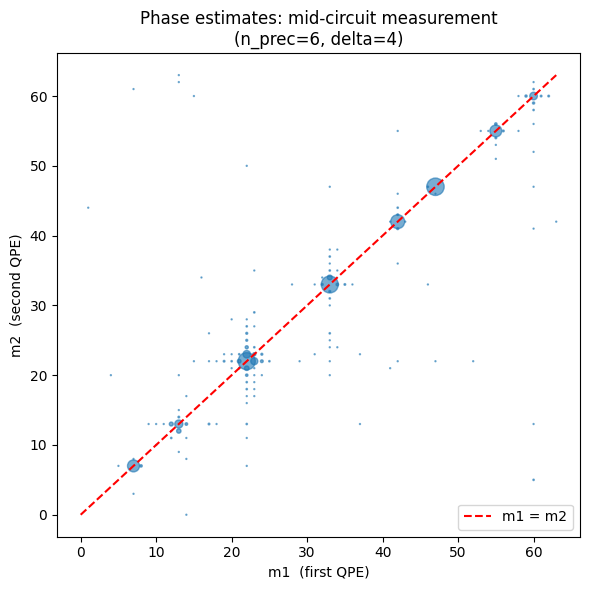

In [39]:
# ── Scatter: m1 vs m2 ──────────────────────────────────────────────────────
m1_vals, m2_vals, weights = [], [], []
for outcome, count in counts.items():
    m1, m2 = parse_outcome(outcome, n_prec)
    m1_vals.append(m1)
    m2_vals.append(m2)
    weights.append(count)

fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(m1_vals, m2_vals, s=np.array(weights) * 0.5, alpha=0.6)
ax.plot([0, 2**n_prec - 1], [0, 2**n_prec - 1], 'r--', label='m1 = m2')
ax.set_xlabel('m1  (first QPE)')
ax.set_ylabel('m2  (second QPE)')
ax.set_title(f'Phase estimates: mid-circuit measurement\n(n_prec={n_prec}, delta={delta})')
ax.legend()
plt.tight_layout()
plt.show()

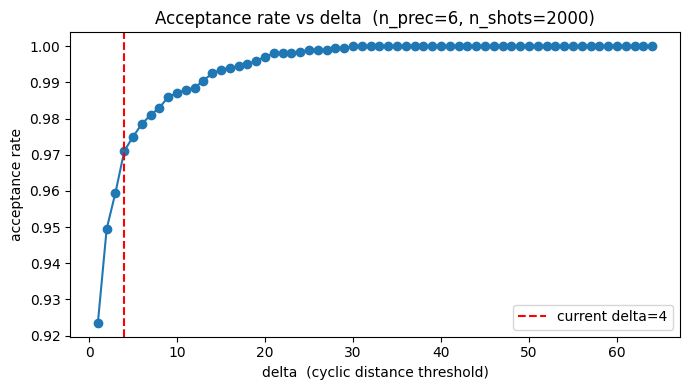


delta → acceptance rate
  delta=  1: 0.923
  delta=  2: 0.950
  delta=  3: 0.960
  delta=  4: 0.971
  delta=  5: 0.975
  delta=  6: 0.979
  delta=  7: 0.981
  delta=  8: 0.983
  delta=  9: 0.986
  delta= 10: 0.987
  delta= 11: 0.988
  delta= 12: 0.989
  delta= 13: 0.991
  delta= 14: 0.993
  delta= 15: 0.994
  delta= 16: 0.994
  delta= 17: 0.995
  delta= 18: 0.995
  delta= 19: 0.996
  delta= 20: 0.997
  delta= 21: 0.998
  delta= 22: 0.998
  delta= 23: 0.998
  delta= 24: 0.999
  delta= 25: 0.999
  delta= 26: 0.999
  delta= 27: 0.999
  delta= 28: 1.000
  delta= 29: 1.000
  delta= 30: 1.000
  delta= 31: 1.000
  delta= 32: 1.000
  delta= 33: 1.000
  delta= 34: 1.000
  delta= 35: 1.000
  delta= 36: 1.000
  delta= 37: 1.000
  delta= 38: 1.000
  delta= 39: 1.000
  delta= 40: 1.000
  delta= 41: 1.000
  delta= 42: 1.000
  delta= 43: 1.000
  delta= 44: 1.000
  delta= 45: 1.000
  delta= 46: 1.000
  delta= 47: 1.000
  delta= 48: 1.000
  delta= 49: 1.000
  delta= 50: 1.000
  delta= 51: 1.000
  delt

In [44]:
# ── Acceptance rate vs delta ────────────────────────────────────────────────
delta_values  = list(range(1, 2 ** (n_prec ) + 1))
accept_rates  = []
worst_cases = []

for d in delta_values:
    acc = sum(
        count for outcome, count in counts.items()
        if cyclic_distance(*parse_outcome(outcome, n_prec), n_prec) <= d
    )
    accept_rates.append(acc / total)
    worst_cases.append(lower_bound_verified_prob(d))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(delta_values, accept_rates, marker='o')
ax.axvline(delta, color='r', linestyle='--', label=f'current delta={delta}')
#ax.plot(delta_values, worst_cases, marker='x', color = 'red', label = "Worst Case Lower Bound")
ax.set_xlabel('delta  (cyclic distance threshold)')
ax.set_ylabel('acceptance rate')
ax.set_title(f'Acceptance rate vs delta  (n_prec={n_prec}, n_shots={n_shots})')
ax.legend()
plt.tight_layout()
plt.show()

print('\ndelta → acceptance rate')
for d, r in zip(delta_values, accept_rates):
    print(f'  delta={d:3d}: {r:.3f}')

## Notes / Interpretation

**Why mid-circuit measurement matters:**

| Approach | What happens between QPE1 and QPE2 |
|----------|------------------------------------|
| Braket single-circuit | No collapse — `prec1`, `prec2`, and `target` remain entangled until the final joint measurement |
| **This notebook** | `prec1` is measured mid-circuit → **target collapses** to a definite eigenstate of U |

Because the target is projected onto a phase eigenstate after the first measurement:
- QPE2 always sees the *same* eigenstate whose phase QPE1 just measured.
- Both estimates therefore track the same eigenvalue → `m1 ≈ m2` on every shot.
- The acceptance rate is high (close to 1 for small `delta`) and determined primarily by QPE's finite-precision error, *not* by eigenstate mixing.

**Scalability note:** For a larger unitary (`n_targ > 1`), replace `n_targ` and increase `n_prec` accordingly. The `UnitaryGate` approach works with the `AerSimulator` for moderate sizes; for real hardware you would need to decompose the unitary into native gates.